# IFT 6758 - Devoir 3 

### Pt 1. Reddit Weekends

Évaluation pour ce notebook:

- Histogrammes pour les counts de base, les counts transformés, et les counts du théorème limite central
- Réponses courtes (dernière section)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
from datetime import date
import scipy.stats as sp

In [4]:
import reddit_weekends

## 1. Charger les données

Lire les données JSON et filtrer/nettoyer le dataframe

In [5]:
raw_df = reddit_weekends.read_data("data/reddit-counts.json.gz")

In [6]:
raw_df.head()

,date,subreddit,comment_count
0,2012-02-20,newfoundland,7
1,2015-01-26,Manitoba,1
2,2013-09-07,Yukon,2
3,2014-02-15,saskatchewan,5
4,2014-07-06,canada,1652


In [30]:
# TODO: Complétez ces implémentations dans reddit_weekends.py
df = reddit_weekends.process_data(raw_df)
wd, we = reddit_weekends.split_data(df)
wd.head()
print('--')
we.head()

--


,date,comment_count,is_weekend
179,2012-02-04,1196,True
251,2012-11-17,1570,True
401,2013-07-14,908,True
479,2013-06-22,984,True
495,2012-07-29,1199,True


### T-Test

In [8]:
# TODO: Complétez ces implémentations dans reddit_weekends.py
p_ttest, p_wdNormal, p_weNormal, p_vartest = reddit_weekends.tests(wd, we, verbose=True)

p_value:	0.0
WD normality:	0.0
WE normality:	0.00014
Variance test:	0.04379


### Solution 1: transformer les données pourrait nous aider

Jetez un oeil à l'histogramme des données. Vous remarquerez qu'il est biaisé: c'est la raison pour laquelle il n'a pas été distribué normalement dans la dernière partie. Essayez de transformer les décomptes afin que les données n'échouent pas au test de normalité. Considérez les transformations suivantes :

     np.log, np.exp, np.sqrt, counts**2
    
Pour chaque transformation, tracez le nouvel histogramme (`reddit_weekends.draw_histogram()`) et exécutez la méthode `reddit_weekends.tests()` pour voir si vous pouvez maintenant utiliser le test T.
    
Remarque: aucune d'entre elles ne fera passer le test de normalité aux deux distributions. Le mieux que vous pouvez obtenir est une variable avec des problèmes de normalité, une bonne; pas de problèmes de variance égale.

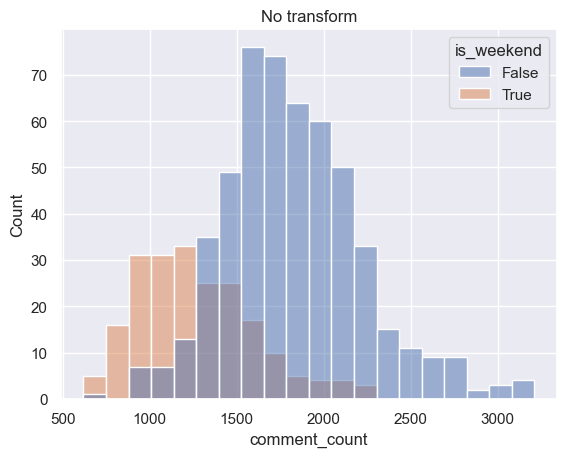

In [9]:
fig = reddit_weekends.draw_histogram(df, title="No transform")

p_value:	0.0
WD normality:	0.00128
WE normality:	0.67909
Variance test:	0.00042


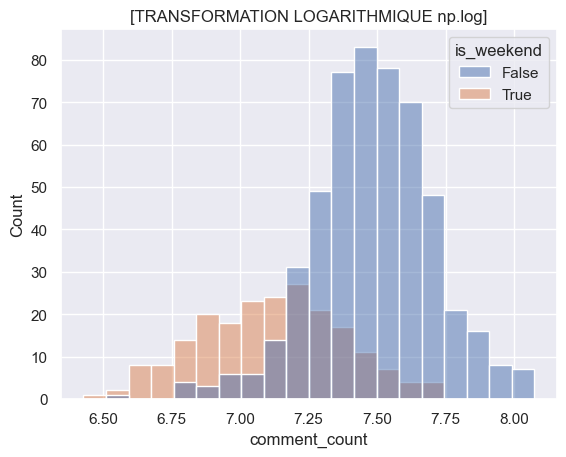

In [19]:
tmp_df = df.copy()

# TODO: Appliquez les transformations aux données copiées (ne modifiez pas le dataframe original!)

# TODO: Tracez l'histogramme
tmp_df['comment_count'] = np.log(df['comment_count'])
reddit_weekends.draw_histogram(tmp_df, title="[TRANSFORMATION LOGARITHMIQUE np.log]")

# TODO: Exécutez les tests à nouveau
_wd, _we = reddit_weekends.split_data(tmp_df)
_ = reddit_weekends.tests(_wd, _we, verbose=True)

TRANSFORMATION EXPONENTIELLE NORMALISÉE
p_value:	0.0
WD normality:	0.0
WE normality:	0.0
Variance test:	9e-05
TRANSFORMATION RACINE CARREE
p_value:	0.0
WD normality:	0.01567
WE normality:	0.06711
Variance test:	0.55605
TRANSFORMATION AU CARREE
p_value:	0.0
WD normality:	0.0
WE normality:	0.0
Variance test:	0.0


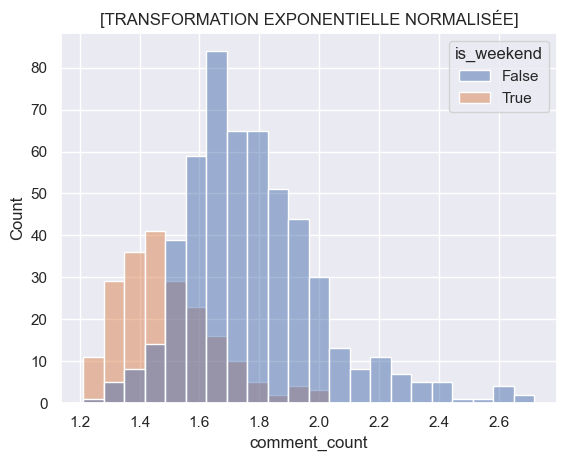

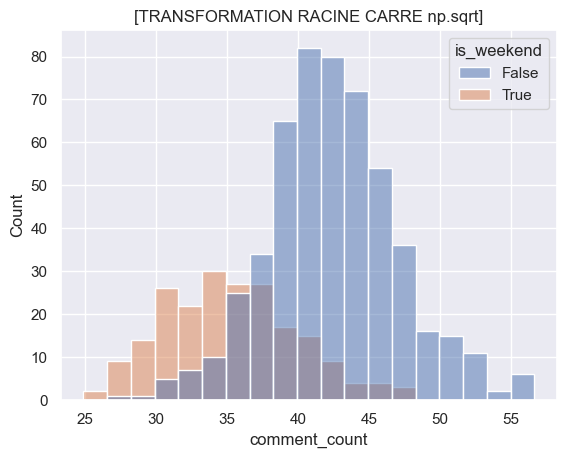

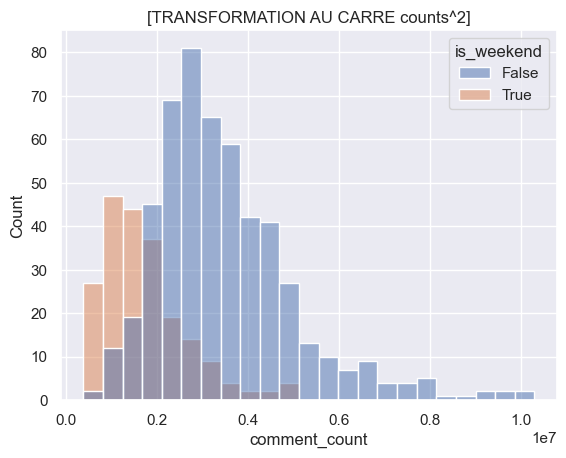

In [20]:
# TODO: RÉPÉTEZ POUR LES AUTRES TRANSFORMATIONS

tmp_df = df.copy()

# TODO: Appliquez les transformations aux données copiées (ne modifiez pas le dataframe original!)

# TODO: Tracez l'histogramme
tmp_df['comment_count'] = tmp_df['comment_count'] / tmp_df['comment_count'].max() # normaliser
tmp_df['comment_count'] = np.exp(tmp_df['comment_count'])
reddit_weekends.draw_histogram(tmp_df, title="[TRANSFORMATION EXPONENTIELLE NORMALISÉE]")

# TODO: Exécutez les tests à nouveau
print('TRANSFORMATION EXPONENTIELLE NORMALISÉE')
_wd, _we = reddit_weekends.split_data(tmp_df)
_ = reddit_weekends.tests(_wd, _we, verbose=True)

#-------------------------------------------------------------------------------------------------

tmp_df = df.copy()

# TODO: Appliquez les transformations aux données copiées (ne modifiez pas le dataframe original!)

# TODO: Tracez l'histogramme
tmp_df['comment_count'] = np.sqrt(df['comment_count'])
reddit_weekends.draw_histogram(tmp_df, title="[TRANSFORMATION RACINE CARRE np.sqrt]")

# TODO: Exécutez les tests à nouveau
print('TRANSFORMATION RACINE CARREE')
_wd, _we = reddit_weekends.split_data(tmp_df)
_ = reddit_weekends.tests(_wd, _we, verbose=True)

#-------------------------------------------------------------------------------------------------

tmp_df = df.copy()

# TODO: Appliquez les transformations aux données copiées (ne modifiez pas le dataframe original!)

# TODO: Tracez l'histogramme
tmp_df['comment_count'] = df['comment_count'] ** 2
reddit_weekends.draw_histogram(tmp_df, title="[TRANSFORMATION AU CARRE counts^2]")

# TODO: Exécutez les tests à nouveau
print('TRANSFORMATION AU CARREE')
_wd, _we = reddit_weekends.split_data(tmp_df)
_ = reddit_weekends.tests(_wd, _we, verbose=True)



# Correction 2: le théorème central limite pourrait nous sauver.

Le théorème central limite dit que si nos nombres sont suffisamment grands et que nous examinons les moyennes de l'échantillon, alors le résultat devrait être normal.
Essayons cela: nous combinerons tous les jours de semaine et de week-end de chaque paire année/semaine et prendrons la moyenne de leurs décomptes (non transformés).

Astuces: vous pouvez obtenir une "année" et un "numéro de semaine" à partir des deux premières valeurs renvoyées par date.isocalendar(). Cette année et ce numéro de semaine vous donneront un identifiant pour la semaine. Utilisez Pandas pour regrouper par cette valeur et agréger en prenant la moyenne. 

Remarque: l'année renvoyée par isocalendar n'est pas toujours la même que l'année de la date (autour de la nouvelle année). Utilisez l'année de l'isocalendar qui est correcte dans ce cas.

Vérifiez ces valeurs pour la normalité et la variance égale. Appliquez un test T si cela a du sens. (Indice : youpi !)

Nous devrions noter que nous modifions subtilement la question ici. La nouvelle questions ressemble plutôt à "le nombre de commentaires le week-end diffère-t-il du nombre de commentaires les jours de semaine pour chaque semaine?"

In [15]:
# TODO: Complétez ces implémentations dans reddit_weekends.py
clt = reddit_weekends.central_limit_theorem(df)
clt.head()

,comment_count,is_weekend
0,995.0,True
1,1561.6,False
2,1163.0,True
3,2062.8,False
4,1372.0,True


p_value:	0.0
WD normality:	0.227
WE normality:	0.09702
Variance test:	0.20384


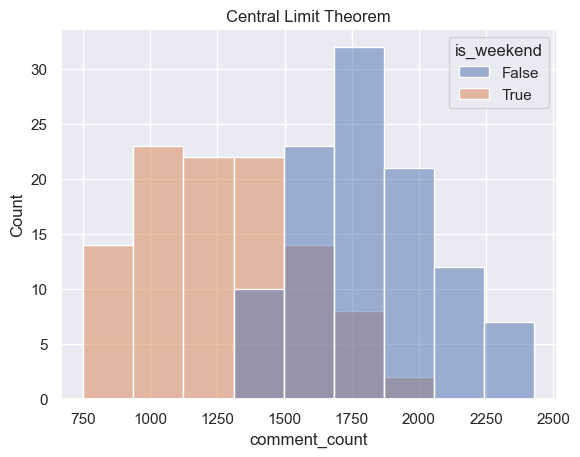

In [16]:
reddit_weekends.draw_histogram(clt, "Central Limit Theorem")

_wd, _we = reddit_weekends.split_data(clt)
_ = reddit_weekends.tests(_wd, _we, verbose=True)

## Correction 3: un test non paramétrique pourrait nous sauver.

L'autre option que nous avons dans notre boîte à outils : un test statistique qui ne se soucie pas autant de la forme de son entrée. Le test U de Mann – Whitney ne suppose pas de valeurs distribuées normalement ni de variance égale.

Effectuez un test U sur les décomptes (initiaux non transformés, non agrégés). Notez que nous devrions faire ici un test bilatéral, qui correspondra aux autres analyses. Assurez-vous que les arguments de la fonction sont corrects.

Encore une fois, notez que nous modifions subtilement la question à nouveau. Si nous parvenons à une conclusion à cause d'un test U, c'est quelque chose comme "il n'est pas également probable qu'il y a un plus grand nombre de commentaires le week-end par rapport aux jours de semaine".

In [31]:
# TODO: Complétez ces implémentations dans reddit_weekends.py
p_utest = reddit_weekends.mann_whitney_u_test(wd, we)
print(f"Mann-Whitney U-test p-value: {p_utest}")

Mann-Whitney U-test p-value: 8.624453234734304e-53


# Réponses courtes

1. Laquelle des quatre transformations suggérées vous rapproche le plus de satisfaire les hypothèses d'un test T ?

*Votre Réponse*

La transformation logarithmique (np.log(comment_count)) est celle qui se rapproche le plus des hypothèses d’un test T : la distribution des week-ends est normale, celle des jours de semaine est quasi normale, et même si les variances restent un peu différentes, c’est la meilleure des quatre options.


2. J'ai donné des explications imprécises en mots de ce que le test hebdomadaire et le test de Mann-Whitney testaient réellement.
    Faites de même pour le test T d'origine et pour le test T des données transformées.
    Autrement dit, décrivez quelle serait la conclusion si vous pouviez rejeter l'hypothèse nulle dans ces tests.

*Votre Réponse*

Le test T d’origine compare les moyennes des commentaires en semaine et le week-end, mais il est invalide ici car les données ne sont pas normales et les variances sont inégales. Le test T sur les données transformées (log) est plus fiable : si on rejette l’hypothèse nulle, cela indique que la différence moyenne entre semaine et week-end est significative. Le test hebdomadaire utilise le théorème central limite pour comparer les moyennes par semaine, offrant une conclusion robuste. Enfin, le test de Mann–Whitney, non paramétrique, montre que les distributions des commentaires diffèrent entre semaine et week-end, sans supposer de normalité.


3. Parmi les quatre approches, laquelle, selon vous, réussit le mieux à obtenir une réponse à la question initiale : "y a-t-il un nombre différent de commentaires Reddit publiés en semaine et le week-end ?"
    Expliquez brièvement pourquoi. (Il n'est pas clair qu'il y ait une seule réponse correcte à cette question, mais il y en a de mauvaises !)

*Votre Réponse*

La meilleure approche est le test hebdomadaire basé sur le théorème central limite, car il compare les moyennes des commentaires par semaine et réduit l’effet des valeurs extrêmes. Grâce au théorème central limite, les moyennes hebdomadaires suivent une distribution quasi normale, ce qui rend le test T fiable. Les autres approches ont des problèmes de normalité, de variance ou se basent sur des données trop brutes, les rendant moins robustes pour répondre à la question.

4. En moyenne, sur Reddit /r/canada, en moyenne: est-ce qu'il y a plus de commentaires publiés en semaine ou le week-end ?

*Ta Réponse*

En moyenne, il y a plus de commentaires publiés en semaine qu’en week-end sur /r/canada. Les tests statistiques confirment que cette différence est significative.